In [134]:
import sys
print(sys.executable)

/home/oni/miniconda3/envs/weatherllm/bin/python


In [135]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.3.1
CUDA available: False
CUDA version: None
Device count: 0


# Data Sources

## NOAA

In [136]:
# Import data from xls file
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pytz


import seaborn as sns

dfd = pd.read_csv('./data/noaa/2023_details.csv')

# For dfd (NOAA data):
# Step 1: Create a combined datetime string
def parse_noaa_datetime(row):
    """
    Parse BEGIN_YEARMONTH, BEGIN_DAY, BEGIN_TIME into a datetime
    """
    year_month = str(int(row['BEGIN_YEARMONTH']))  # e.g., '202301'
    day = str(int(row['BEGIN_DAY'])).zfill(2)  # e.g., '25'
    time_str = str(int(row['BEGIN_TIME'])).zfill(4)  # e.g., '0230' 
    
    # Combine into format: YYYYMMDD HHMM
    datetime_str = f"{year_month}{day} {time_str}"
    
    # Parse to datetime
    return pd.to_datetime(datetime_str, format='%Y%m%d %H%M')

# Apply to dataframe
dfd['datetime'] = dfd.apply(parse_noaa_datetime, axis=1)

# Round to nearest hour to match ERA5 hourly data
dfd['datetime_hourly'] = dfd['datetime'].dt.round('H')

# For dfd - convert to ISO format string
dfd['datetime_iso'] = dfd['datetime_hourly'].dt.strftime('%Y-%m-%dT%H:%M:%S')


# This is the RECOMMENDED approach as it properly handles DST transitions
central_tz = pytz.timezone('America/Chicago')

# Localize the datetime_hourly column to Central timezone
dfd['datetime_central'] = dfd['datetime_hourly'].dt.tz_localize(central_tz, ambiguous='infer', nonexistent='shift_forward')

# Convert to UTC
dfd['datetime_utc'] = dfd['datetime_central'].dt.tz_convert('UTC')

# If you want to remove timezone info but keep the UTC time
dfd['datetime_utc_naive'] = dfd['datetime_utc'].dt.tz_localize(None)

print("Sample conversions:")
print(dfd[['datetime_hourly', 'datetime_utc_naive']].head(10))

# print(dfd[['datetime', 'datetime_hourly', 'datetime_iso']].head(10))


/tmp/ipykernel_20082/1088494204.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dfd['datetime_hourly'] = dfd['datetime'].dt.round('H')


Sample conversions:
      datetime_hourly  datetime_utc_naive
0 2023-10-25 02:00:00 2023-10-25 07:00:00
1 2023-10-25 02:00:00 2023-10-25 07:00:00
2 2023-10-25 02:00:00 2023-10-25 07:00:00
3 2023-10-25 02:00:00 2023-10-25 07:00:00
4 2023-10-25 02:00:00 2023-10-25 07:00:00
5 2023-10-25 02:00:00 2023-10-25 07:00:00
6 2023-06-07 08:00:00 2023-06-07 13:00:00
7 2023-10-01 00:00:00 2023-10-01 05:00:00
8 2023-10-25 02:00:00 2023-10-25 07:00:00
9 2023-08-06 18:00:00 2023-08-06 23:00:00


### Data Filtering

Based on:
- Record must have latitude and longitude information
- Selected States
- Selected date and time

#### Remove data with no latitude/longitude (null values)

In [137]:
# Remove data with no latitude/longitude
dfd = dfd[dfd['BEGIN_LAT'].notnull() | dfd['BEGIN_LON'].notnull()]

#### Selected States and Dates

The first part is focusing on finding the states that has most event of extreme weather, categorized them by weather type. In this case, the categorization will be using heatmap.

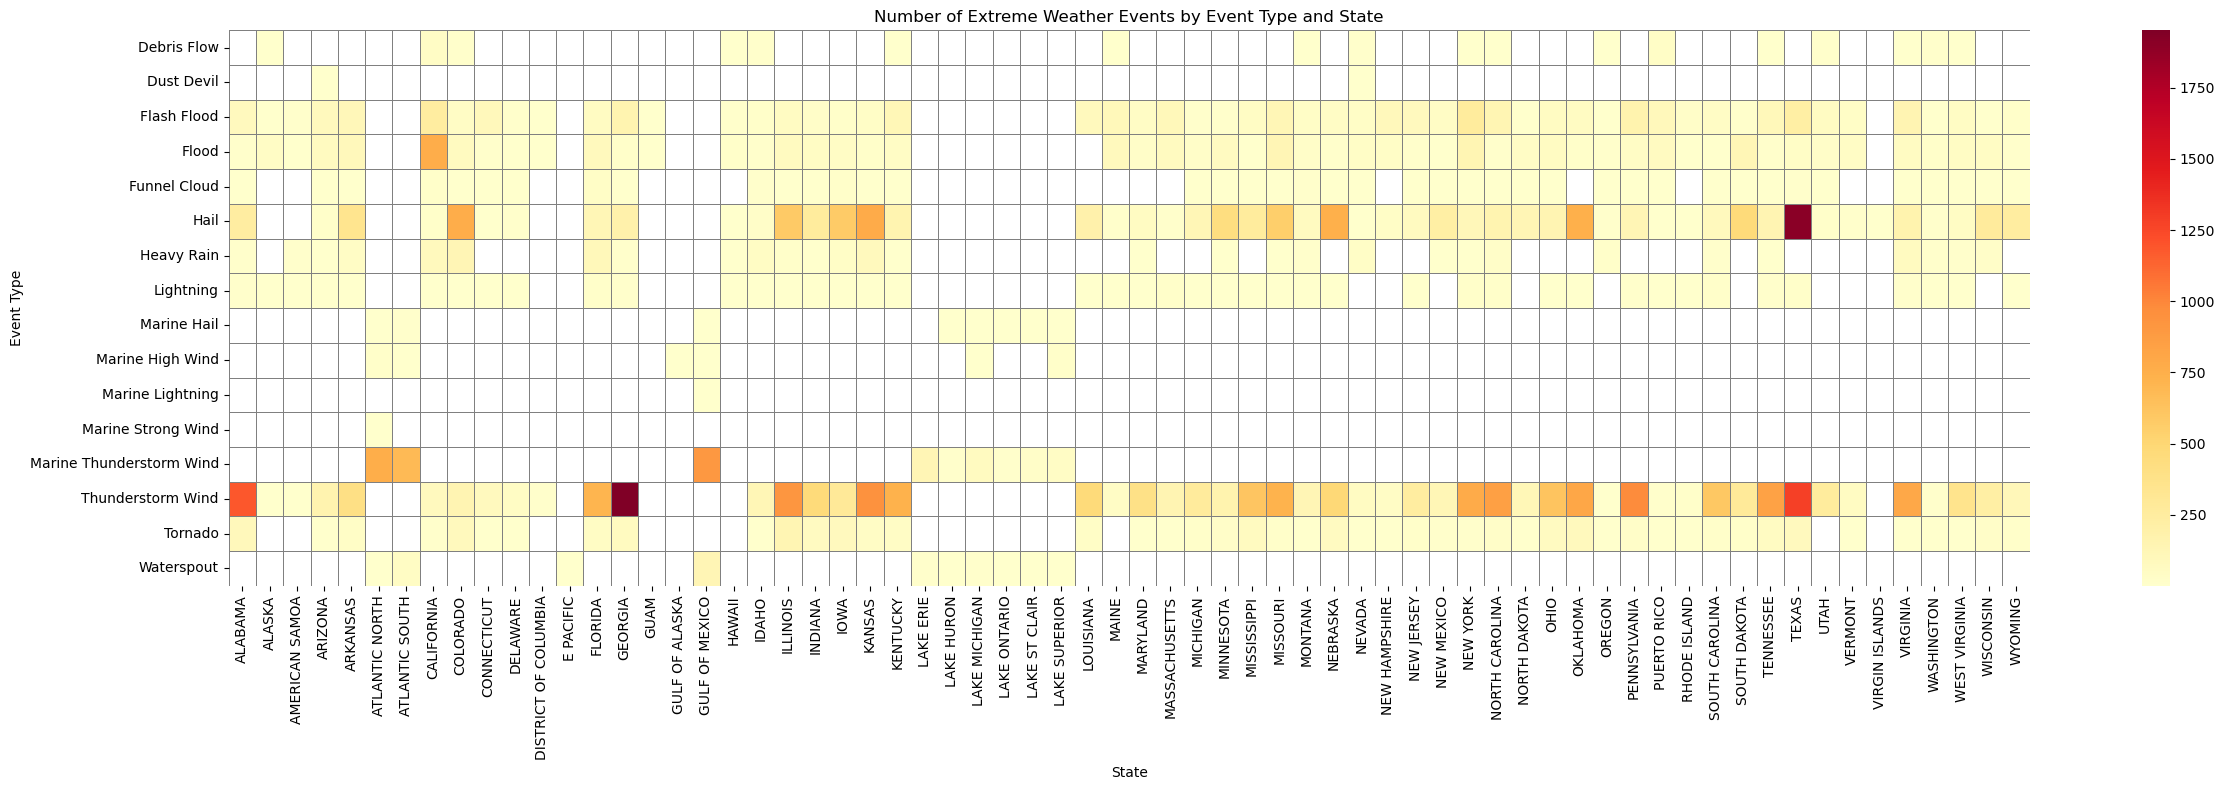

In [138]:
# Create a pivot table: rows=EVENT_TYPE, columns=STATE, values=number of events
heatmap_data = dfd.pivot_table(index='EVENT_TYPE', columns='STATE', aggfunc='size')

plt.figure(figsize=(25, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, linecolor='gray')
plt.title('Number of Extreme Weather Events by Event Type and State')
plt.xlabel('State')
plt.ylabel('Event Type')
plt.tight_layout()
plt.show()


Based on the heatmap, the selected extreme weather for this research is Thunderstorm Wind in Texas. The state of Georgia and Alabama can also be used.

To reduce the number of data being used, we also be focusing on the month where there has most extreme weather condition.

In [139]:
# The states that has the most extreme weather events
STATES_LIST = ["TEXAS"]

# Filter dfd to only include rows where STATE is in STATES_LIST
dfd = dfd[dfd['STATE'].isin(STATES_LIST)]

# Filter dfd to only include rows where EVENT_TYPE is 'Thunderstorm Wind'
# dfd = dfd[dfd['EVENT_TYPE'] == 'Thunderstorm Wind']

# Group by month and count the number of Thunderstorm Wind events
grouped_by_month = dfd.groupby('BEGIN_YEARMONTH').size().reset_index(name='event_count')    
print(grouped_by_month)

print("--------------------------------")

grouped_by_event_type = dfd.groupby('EVENT_TYPE').size().reset_index(name='event_count')
print(grouped_by_event_type)


    BEGIN_YEARMONTH  event_count
0            202301           27
1            202302           64
2            202303          364
3            202304          688
4            202305          654
5            202306         1075
6            202307          162
7            202308           92
8            202309          312
9            202310          119
10           202311            6
11           202312            9
--------------------------------
          EVENT_TYPE  event_count
0        Flash Flood          229
1              Flood           38
2       Funnel Cloud           12
3               Hail         1912
4          Lightning           18
5  Thunderstorm Wind         1281
6            Tornado           82


In [177]:
# Filter dfd for specific date
# specific_date = pd.Timestamp('2023-06-12')  # replace year as appropriate, or set externally
# dfd = dfd[dfd['datetime_utc_naive'].dt.month == specific_date.month]

# Filter dfd for a range of dates
start_date = pd.Timestamp('2023-01-04')  # set your desired start date
end_date = pd.Timestamp('2023-12-30')    # set your desired end date
dfd = dfd[(dfd['datetime_utc_naive'] >= start_date) & (dfd['datetime_utc_naive'] <= end_date)]


# Get distribution of data based on event type
event_type_counts = dfd['EVENT_TYPE'].value_counts().reset_index()
event_type_counts.columns = ['EVENT_TYPE', 'count']
print(event_type_counts)

# print(dfd.shape)

print(f"Sample up to 20 records per event type:")


# Limit the number of rows to a maximum of 20 per event type
dfd = dfd.groupby('EVENT_TYPE').head(20).reset_index(drop=True)
print(dfd['EVENT_TYPE'].value_counts())

          EVENT_TYPE  count
0               Hail     20
1  Thunderstorm Wind     20
2            Tornado     20
3              Flood     20
4        Flash Flood     19
5          Lightning     18
6       Funnel Cloud     12
Sample up to 20 records per event type:
EVENT_TYPE
Hail                 20
Thunderstorm Wind    20
Tornado              20
Flood                20
Flash Flood          19
Lightning            18
Funnel Cloud         12
Name: count, dtype: int64


In [141]:
dfd.shape

(130, 57)

Getting the min and max latitude of the states that becomes the main focus of the data. This information is useful for selecting specific region in ERA5 dataset.

In [142]:
# Find the min and max latitude for each state
min_max_latitude = dfd.groupby('STATE')['BEGIN_LAT'].agg(['min', 'max'])
print("Latitude:")
print(min_max_latitude)

print("")

# Find the min and max longitude for each state
min_max_longitude = dfd.groupby('STATE')['BEGIN_LON'].agg(['min', 'max'])
print("Longitude:")
print(min_max_longitude)

Latitude:
           min      max
STATE                  
TEXAS  25.8951  36.4621

Longitude:
          min      max
STATE                 
TEXAS -104.85 -93.8921


In [143]:
# Get the list of unique EVENT_TYPE
unique_event_types = dfd['EVENT_TYPE'].unique()
print(unique_event_types)


['Hail' 'Thunderstorm Wind' 'Flash Flood' 'Tornado' 'Flood' 'Lightning'
 'Funnel Cloud']


In [144]:
state_event_counts = dfd.groupby('STATE').size().reset_index(name='event_count')
# Focus only on event_type 'Thunderstorm Wind'

# state_event_counts_thunderstorm = dfd.groupby('STATE').size().reset_index(name='event_count')
# print(state_event_counts_thunderstorm)

# print(state_event_counts)

print(dfd['datetime_utc_naive'])

0     2023-05-02 23:00:00
1     2023-05-03 00:00:00
2     2023-05-04 02:00:00
3     2023-05-02 23:00:00
4     2023-05-02 22:00:00
              ...        
125   2023-09-19 22:00:00
126   2023-10-04 15:00:00
127   2023-06-04 00:00:00
128   2023-06-04 00:00:00
129   2023-06-04 17:00:00
Name: datetime_utc_naive, Length: 130, dtype: datetime64[ns]


#### Conform the Latitude and Longitude

Rounding the latitude and longitude in the increment of 0.25. This rounding process will help to conform with the ERA5 dataset in column Time.

In [145]:
# print("BEFORE ROUNDING:")
# print(dfd[['BEGIN_LAT', 'BEGIN_LON']].head(10))

# Round coordinates to match ERA5 0.25 degree grid
dfd['BEGIN_LAT'] = (dfd['BEGIN_LAT'] / 0.25).round() * 0.25
dfd['BEGIN_LON'] = (dfd['BEGIN_LON'] / 0.25).round() * 0.25
dfd['END_LAT'] = (dfd['END_LAT'] / 0.25).round() * 0.25
dfd['END_LON'] = (dfd['END_LON'] / 0.25).round() * 0.25

# print("AFTER ROUNDING:")
# print(dfd[['BEGIN_LAT', 'BEGIN_LON']].head(10))

# Find the min and max latitude for each state
min_max_latitude = dfd.groupby('STATE')['BEGIN_LAT'].agg(['min', 'max'])
print("Latitude:")
print(min_max_latitude)

print("")

# Find the min and max longitude for each state
min_max_longitude = dfd.groupby('STATE')['BEGIN_LON'].agg(['min', 'max'])
print("Longitude:")
print(min_max_longitude)

Latitude:
        min   max
STATE            
TEXAS  26.0  36.5

Longitude:
          min   max
STATE              
TEXAS -104.75 -94.0


### Remove Unnecessary Columns

In [146]:
columns_to_remove = [
    'TOR_F_SCALE', 
    'TOR_LENGTH', 
    'TOR_WIDTH', 
    'TOR_OTHER_WFO', 
    'TOR_OTHER_WFO_ID', 
    'TOR_OTHER_WFO_NAME', 
    'TOR_OTHER_WFO_STATE',
    'TOR_OTHER_CZ_STATE',
    'TOR_OTHER_CZ_FIPS',
    'TOR_OTHER_CZ_NAME',
    'CZ_FIPS',
    'CZ_NAME',
    'CZ_TYPE',
    'DEATHS_DIRECT', 
    'DEATHS_INDIRECT', 
    'INJURIES_DIRECT', 
    'INJURIES_INDIRECT', 
    'DAMAGE_PROPERTY', 
    'DAMAGE_CROPS', 
    'BEGIN_LOCATION',
    'END_LOCATION',
    'YEAR',
    'MONTH_NAME',
    'BEGIN_YEARMONTH',
    'BEGIN_DAY',
    'BEGIN_TIME',
    'END_YEARMONTH',
    'END_DAY',
    'END_TIME',
    'SOURCE',
    'DATA_SOURCE',
    'WFO',
    'EPISODE_ID',
    'STATE_FIPS',
    'BEGIN_DATE_TIME',
    'END_DATE_TIME',
    'BEGIN_RANGE',
    'END_RANGE',
    'BEGIN_AZIMUTH',
    'END_AZIMUTH',
    'MAGNITUDE',
    'MAGNITUDE_TYPE',    
    'EPISODE_NARRATIVE',
    'EVENT_NARRATIVE',
    'CZ_TIMEZONE',
    'FLOOD_CAUSE',
    'CATEGORY',
    'datetime_hourly',
    'datetime',
    'EVENT_ID',
    'datetime_iso', 'datetime_central', 'datetime_utc', 'datetime_utc_iso']
    
dfd = dfd.drop(columns=columns_to_remove, errors='ignore')


Add column has_extreme_weather as an True/False indicator whether there's a extreme event at the time and location (latitude, longitude).

In [147]:
# Mark all rows as having extreme weather
dfd['has_extreme_weather'] = True

In [148]:
# # 1. Define your time range
# start_date = dfd['datetime_utc_naive'].min().floor('H')
# end_date = dfd['datetime_utc_naive'].max().ceil('H')
# hourly_range = pd.date_range(start=start_date, end=end_date, freq='H')

# # print(hourly_range)

# # 2. Get unique locations (you might want to round coordinates to a grid)
# locations = dfd[['BEGIN_LAT', 'BEGIN_LON']].drop_duplicates()

# # 3. Create a full cartesian product of all hours × all locations
# from itertools import product
# hourly_grid = pd.DataFrame(
#     list(product(hourly_range, locations.itertuples(index=False))),
#     columns=['datetime_utc_naive', 'location']
# )

# print(hourly_grid)

# hourly_grid[['BEGIN_LAT', 'BEGIN_LON']] = pd.DataFrame(
#     hourly_grid['location'].tolist(), index=hourly_grid.index
# )

# # 4. Mark which hours had extreme weather events
# # hourly_grid['has_extreme_weather'] = 0
# # Merge with your events to flag extreme weather hours
# hourly_grid = hourly_grid.merge(dfd, on=['BEGIN_LAT', 'BEGIN_LON', 'datetime_utc_naive'], how='outer')

# # Sort hourly_grid by datetime_utc_naive and location
# hourly_grid = hourly_grid.sort_values(by=['datetime_utc_naive', 'location']).reset_index(drop=True)

# # print(hourly_grid)

### Create Grid Points

Create grid points for NOAA data based of datetime, latitude and longitude. The location bounds are set to match the data from ERA5 with increments of 0.25 degree.

The location bounds are:
- Latitude  : (26.0, 36.5)
- Longitude : (-106.75, -94.0)

In [149]:
from itertools import product
import numpy as np

HOURS_BEFORE = 8
HOURS_AFTER = 2

# 1. Define your time range (same as before)
start_date = dfd['datetime_utc_naive'].min().floor('H')-pd.Timedelta(hours=HOURS_BEFORE)
end_date = dfd['datetime_utc_naive'].max().ceil('H')+pd.Timedelta(hours=HOURS_AFTER)
hourly_range = pd.date_range(start=start_date, end=end_date, freq='H')

print(start_date, end_date)

# 2. Instead of getting unique locations from dfd, create FULL grid
# Get the min/max bounds from your data
# lat_min = dfd['BEGIN_LAT'].min()
# lat_max = dfd['BEGIN_LAT'].max()
# lon_min = dfd['BEGIN_LON'].min()
# lon_max = dfd['BEGIN_LON'].max()

# Or you can manually set bounds for your region, e.g.:
lat_min, lat_max = 26.0, 36.5  # Texas region
lon_min, lon_max = -106.75, -94.0

# Create all lat/lon combinations with 0.25 degree increments
lats = np.arange(lat_min, lat_max + 0.25, 0.25)
lons = np.arange(lon_min, lon_max + 0.25, 0.25)

# Round to avoid floating point precision issues
lats = np.round(lats, 2)
lons = np.round(lons, 2)

# Create all location combinations
all_locations = list(product(lats, lons))

print(f"Time steps: {len(hourly_range)}")
print(f"Latitude points: {len(lats)} (from {lat_min} to {lat_max})")
print(f"Longitude points: {len(lons)} (from {lon_min} to {lon_max})")
print(f"Total locations: {len(all_locations)}")
print(f"Total grid points: {len(hourly_range) * len(all_locations)}")

# 3. Create full cartesian product of all hours × all locations
hourly_grid = pd.DataFrame(
    list(product(hourly_range, all_locations)),
    columns=['datetime_utc_naive', 'location']
)

# 4. Split the location tuple into separate columns
hourly_grid[['BEGIN_LAT', 'BEGIN_LON']] = pd.DataFrame(
    hourly_grid['location'].tolist(), index=hourly_grid.index
)

# Drop the location tuple column if not needed
hourly_grid = hourly_grid.drop('location', axis=1)

print(f"\nFinal grid shape: {hourly_grid.shape}")

# 5. Merge with your events to flag extreme weather hours
hourly_grid = hourly_grid.merge(
    dfd, 
    on=['BEGIN_LAT', 'BEGIN_LON', 'datetime_utc_naive'], 
    how='left'  # Use 'left' to keep all grid points
)

# # 6. Sort by datetime and location
# hourly_grid = hourly_grid.sort_values(
#     by=['datetime_utc_naive', 'BEGIN_LAT', 'BEGIN_LON']
# ).reset_index(drop=True)

print(f"\nFinal grid shape: {hourly_grid.shape}")
# print(hourly_grid.head())

2023-01-02 18:00:00 2023-10-04 17:00:00
Time steps: 6600
Latitude points: 43 (from 26.0 to 36.5)
Longitude points: 52 (from -106.75 to -94.0)
Total locations: 2236
Total grid points: 14757600


/tmp/ipykernel_20082/3137617820.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_date = dfd['datetime_utc_naive'].min().floor('H')-pd.Timedelta(hours=HOURS_BEFORE)
/tmp/ipykernel_20082/3137617820.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_date = dfd['datetime_utc_naive'].max().ceil('H')+pd.Timedelta(hours=HOURS_AFTER)
/tmp/ipykernel_20082/3137617820.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_range = pd.date_range(start=start_date, end=end_date, freq='H')



Final grid shape: (14757600, 3)

Final grid shape: (14757611, 8)


In [150]:
# # Check for duplicate location-time combinations in dfd
# duplicates = dfd.groupby(['BEGIN_LAT', 'BEGIN_LON', 'datetime_utc_naive']).size()
# print(f"Max events at same location/time: {duplicates.max()}")
# print(f"Number of location-time combos with multiple events: {(duplicates > 1).sum()}")

# print(duplicates)

Replace the NaN data with:
- has_extreme_weather --> False     (there's no extreme weather event)
- EVENT_TYPE --> NA                 (there's no extreme weather event)
- STATE --> Texas

In [151]:
# Convert NaN to False
hourly_grid['has_extreme_weather'] = hourly_grid['has_extreme_weather'].fillna(False)

# Convert NaN to 'NA'
hourly_grid['EVENT_TYPE'] = hourly_grid['EVENT_TYPE'].fillna('NA')

# Update 'STATE' column in hourly_grid to "Texas" for all rows
hourly_grid['STATE'] = 'Texas'

# Fill Nan in END_LAT and END_LON
hourly_grid['END_LAT'] = hourly_grid['END_LAT'].fillna(hourly_grid['BEGIN_LAT'])
hourly_grid['END_LON'] = hourly_grid['END_LON'].fillna(hourly_grid['BEGIN_LON'])

hourly_grid.head()

/tmp/ipykernel_20082/404433841.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hourly_grid['has_extreme_weather'] = hourly_grid['has_extreme_weather'].fillna(False)


,datetime_utc_naive,BEGIN_LAT,BEGIN_LON,STATE,EVENT_TYPE,END_LAT,END_LON,has_extreme_weather
0,2023-01-02 18:00:00,26.0,-106.75,Texas,NA,26.0,-106.75,False
1,2023-01-02 18:00:00,26.0,-106.50,Texas,NA,26.0,-106.50,False
2,2023-01-02 18:00:00,26.0,-106.25,Texas,NA,26.0,-106.25,False
3,2023-01-02 18:00:00,26.0,-106.00,Texas,NA,26.0,-106.00,False
4,2023-01-02 18:00:00,26.0,-105.75,Texas,NA,26.0,-105.75,False


In [152]:
for col in hourly_grid.columns:
    print(col)

print('--------------------------------')

for col in ['EVENT_TYPE', 'STATE', 'has_extreme_weather']:
    print(hourly_grid[col].value_counts(dropna=False))
    print("--------------------------------")


datetime_utc_naive
BEGIN_LAT
BEGIN_LON
STATE
EVENT_TYPE
END_LAT
END_LON
has_extreme_weather
--------------------------------
EVENT_TYPE
NA                   14757481
Flash Flood                20
Thunderstorm Wind          20
Tornado                    20
Flood                      20
Hail                       20
Lightning                  18
Funnel Cloud               12
Name: count, dtype: int64
--------------------------------
STATE
Texas    14757611
Name: count, dtype: int64
--------------------------------
has_extreme_weather
False    14757481
True          130
Name: count, dtype: int64
--------------------------------


In [153]:
# Export to CSV
hourly_grid.to_csv('./data/csv/noaa_hourly_grid.csv', index=False)

## ERA5 Data

Based on the data, the datasets are separated into two groups based on the characteristic of how the data being generated. 
- dsA (dataset 0) has the dimension of (time: 5880, lat: 45, long: 53)
- dsB (dataset 1) has the dimension of (time: 491, step: 12 lat: 45, long: 53)

In [154]:
import cfgrib
import xarray as xr

datasets = cfgrib.open_datasets('./data/era5/era5_2023_texas_new.grib')

# Get the first and second group of datasets
dsA = datasets[0]
dsB = datasets[1]

/home/oni/miniconda3/envs/weatherllm/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:132: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/oni/miniconda3/envs/weatherllm/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:132: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/home/oni/miniconda3/envs/weatherllm/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:132: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' i

In [155]:
# Sort both by time
dsA = dsA.sortby("time")
dsB = dsB.sortby("time")

# Convert time to pandas datetime
dsA['time'] = pd.to_datetime(dsA.time.values)
dsB['time'] = pd.to_datetime(dsB.time.values)

print(dsA.dims)
print(dsB.dims)

FrozenMappingWarningOnValuesAccess({'time': 8760, 'latitude': 43, 'longitude': 52})
FrozenMappingWarningOnValuesAccess({'time': 731, 'step': 12, 'latitude': 43, 'longitude': 52})


In [156]:
lat_min = dsA['latitude'].min().item()
lat_max = dsA['latitude'].max().item()
lon_min = dsA['longitude'].min().item()
lon_max = dsA['longitude'].max().item()

print(lat_min, lat_max)
print(lon_min, lon_max)

26.0 36.5
-106.75 -94.0


### Combining Time and Step

This process combines both time and step in dsB into a new dimension, which make dsB dimension into (time: 5892, lat: 45, long: 53). The new dimension (time) will replace the previous time and step dimension.

In [157]:
print(dsB.time[0].values, dsB.time[-1].values)
print("================================================")

# Calculate valid_time for each (time, step) combination
valid_time = dsB["time"] + dsB["step"]

# Stack both the data and valid_time together
ds_stacked = dsB.stack(ts=("time", "step"))
valid_time_stacked = valid_time.stack(ts=("time", "step"))

# IMPORTANT: Drop the multi-index coordinates FIRST to avoid conflicts
ds_hourly = ds_stacked.reset_coords(drop=True)
ds_hourly = ds_hourly.drop_vars(['time', 'step'], errors='ignore')

# NOW rename the dimension and assign new coordinate values
ds_hourly = ds_hourly.rename({'ts': 'time'})
ds_hourly = ds_hourly.assign_coords(time=valid_time_stacked.values)

# Sort by time
ds_hourly = ds_hourly.sortby('time')

# Remove duplicate times if they exist
_, unique_indices = np.unique(ds_hourly['time'].values, return_index=True)
ds_hourly = ds_hourly.isel(time=sorted(unique_indices))

dsB = ds_hourly

print(dsB.time[0].values, dsB.time[-1].values)
print("================================================")

print(f"Final time shape: {dsB.time.shape}")
print(f"Final dimensions: {dict(dsB.dims)}")

2022-12-31T18:00:00.000000000 2023-12-31T18:00:00.000000000
2022-12-31T19:00:00.000000000 2024-01-01T06:00:00.000000000
Final time shape: (8772,)
Final dimensions: {'latitude': 43, 'longitude': 52, 'time': 8772}


/tmp/ipykernel_20082/783414215.py:13: DeprecationWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'ts'} to avoid an error in the future.
  ds_hourly = ds_hourly.drop_vars(['time', 'step'], errors='ignore')
/tmp/ipykernel_20082/783414215.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Final dimensions: {dict(dsB.dims)}")


In [158]:
# Convert time to pandas datetime
dsA['time'] = pd.to_datetime(dsA.time.values)
dsB['time'] = pd.to_datetime(dsB.time.values)

# # IMPORTANT: Transpose dsB to match dsA's dimension order BEFORE reindexing
dsB = dsB.transpose('time', 'latitude', 'longitude')

# # Check time alignment
print(f"dsA time range: {dsA.time.values[0]} to {dsA.time.values[-1]}")
print(f"dsB time range: {dsB.time.values[0]} to {dsB.time.values[-1]}")
print(f"dsA shape: {dsA.dims}")
print(f"dsB shape: {dsB.dims}")

# Reindex dsB to match dsA's time coordinate
# Use a more lenient tolerance or interpolation
dsB_on_A = dsB.interp(time=dsA.time, method='nearest', kwargs={"fill_value": "extrapolate"})

# Alternative: If interpolation doesn't work, use reindex with no tolerance
# dsB_on_A = dsB.reindex(time=dsA.time, method='nearest')

# Verify that cp values are preserved
print(f"\nBefore merge - dsB cp non-NaN count: {np.sum(~np.isnan(dsB['tp'].values))}")
print(f"After reindex - dsB_on_A cp non-NaN count: {np.sum(~np.isnan(dsB_on_A['tp'].values))}")

# Merge with proper compatibility handling
ds = xr.merge([dsA, dsB_on_A], compat="no_conflicts")

# Verify merge result
print(f"After merge - ds tp non-NaN count: {np.sum(~np.isnan(ds['tp'].values))}")
print(ds.data_vars)
print(ds.dims)

print(f"ds Merge time range: {ds.time.values[0]} to {ds.time.values[-1]}")

dsA time range: 2023-01-01T00:00:00.000000000 to 2023-12-31T23:00:00.000000000
dsB time range: 2022-12-31T19:00:00.000000000 to 2024-01-01T06:00:00.000000000
dsA shape: FrozenMappingWarningOnValuesAccess({'time': 8760, 'latitude': 43, 'longitude': 52})
dsB shape: FrozenMappingWarningOnValuesAccess({'latitude': 43, 'longitude': 52, 'time': 8772})

Before merge - dsB cp non-NaN count: 19587360
After reindex - dsB_on_A cp non-NaN count: 19587360
After merge - ds tp non-NaN count: 19587360
Data variables:
    sst      (time, latitude, longitude) float32 78MB ...
    sp       (time, latitude, longitude) float32 78MB ...
    msl      (time, latitude, longitude) float32 78MB ...
    u10      (time, latitude, longitude) float32 78MB ...
    v10      (time, latitude, longitude) float32 78MB ...
    t2m      (time, latitude, longitude) float32 78MB ...
    d2m      (time, latitude, longitude) float32 78MB ...
    u100     (time, latitude, longitude) float32 78MB ...
    v100     (time, latitude,

#### Validate the values in dsB data_vars

Making sure that the value from dsB are not being replaced by NaN fater merging.

In [159]:
tpVal = ds['tp'].values
mask_not_nan = ~np.isnan(tpVal)
tpVal_not_nan = tpVal[mask_not_nan]
print("tp values from dsB where not nan:", tpVal_not_nan.shape)

i10fgVal = ds['i10fg'].values
mask_not_nan = ~np.isnan(i10fgVal)
i10fgVal_not_nan = i10fgVal[mask_not_nan]
print("i10fg values from dsB where not nan:", i10fgVal_not_nan.shape)

tp values from dsB where not nan: (19587360,)
i10fg values from dsB where not nan: (19587360,)


In [160]:
# Apply chunking for Dask
ds = ds.chunk({
    'time': 200,
    'latitude': -1,
    'longitude': -1
})

# Convert time to pandas datetime
# ds['time'] = pd.to_datetime(ds.time.values)

print("\n✅ Dataset loaded with all variables:")
print(f"Total variables: {len(ds.data_vars)}")
print(f"Variables: {sorted(list(ds.data_vars.keys()))}")
print(f"\nDataset info:")
print(ds)


✅ Dataset loaded with all variables:
Total variables: 11
Variables: ['d2m', 'i10fg', 'msl', 'sp', 'sst', 't2m', 'tp', 'u10', 'u100', 'v10', 'v100']

Dataset info:
<xarray.Dataset> Size: 862MB
Dimensions:     (time: 8760, latitude: 43, longitude: 52)
Coordinates:
    number      int64 8B 0
  * time        (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
  * latitude    (latitude) float64 344B 36.5 36.25 36.0 ... 26.5 26.25 26.0
  * longitude   (longitude) float64 416B -106.8 -106.5 -106.2 ... -94.25 -94.0
    valid_time  (time) datetime64[ns] 70kB dask.array<chunksize=(200,), meta=np.ndarray>
Data variables:
    sst         (time, latitude, longitude) float32 78MB dask.array<chunksize=(200, 43, 52), meta=np.ndarray>
    sp          (time, latitude, longitude) float32 78MB dask.array<chunksize=(200, 43, 52), meta=np.ndarray>
    msl         (time, latitude, longitude) float32 78MB dask.array<chunksiz

In [161]:
# # Print a sample of 5 rows of the dataset for all variables
# print("\n📝 Sample 5 rows from the dataset (all variables):")
# print(ds.to_dataframe().reset_index().head(5))

# Merging NOAA and ERA5 Datasets

## Without Time Window



In [162]:
print(f"Grid shape: {hourly_grid.shape}")

# Extract coordinates as numpy arrays
times = hourly_grid['datetime_utc_naive'].values
lats = hourly_grid['BEGIN_LAT'].values
lons = hourly_grid['BEGIN_LON'].values

print(f"Total points to extract: {len(times)}")
print(f"Unique times: {len(np.unique(times))}")
print(f"Unique lats: {len(np.unique(lats))}")
print(f"Unique lons: {len(np.unique(lons))}")

Grid shape: (14757611, 8)
Total points to extract: 14757611
Unique times: 6600
Unique lats: 43
Unique lons: 52


### Create Indices for datetime, latitude and longitude

In [163]:
# Convert ds times to numpy array
ds_times = ds.time.values  # This gives numpy datetime64 array
ds_lats = ds.latitude.values
ds_lons = ds.longitude.values

# Vectorized nearest neighbor search for numeric values
def find_nearest_indices_numeric(query_vals, reference_vals):
    """Find nearest index for each query value in reference array"""
    distances = np.abs(query_vals[:, np.newaxis] - reference_vals[np.newaxis, :])
    nearest_idx = np.argmin(distances, axis=1)
    return nearest_idx

# For datetime: convert to int64 (nanoseconds since epoch)
def find_nearest_indices_datetime_chunked(query_times, reference_times, chunk_size=100000):
    """Find nearest index for datetime arrays, processing in chunks"""
    # Convert to int64 (nanoseconds)
    query_ns = query_times.astype('datetime64[ns]').astype(np.int64)
    ref_ns = reference_times.astype('datetime64[ns]').astype(np.int64)
    
    nearest_idx = np.zeros(len(query_ns), dtype=np.int64)
    
    for start in range(0, len(query_ns), chunk_size):
        end = min(start + chunk_size, len(query_ns))
        chunk = query_ns[start:end]
        distances = np.abs(chunk[:, np.newaxis] - ref_ns[np.newaxis, :])
        nearest_idx[start:end] = np.argmin(distances, axis=1)
        
        if (start // chunk_size + 1) % 5 == 0:
            print(f"Processed {end}/{len(query_ns)} time lookups")
    
    return nearest_idx

# Find indices for all points at once
# For times: use the datetime-specific function
time_indices = find_nearest_indices_datetime_chunked(times, ds_times)

# For lat/lon: use the numeric function
lat_indices = find_nearest_indices_numeric(lats, ds_lats)
lon_indices = find_nearest_indices_numeric(lons, ds_lons)

print(f"Time indices range: {time_indices.min()} to {time_indices.max()}")
print(f"Lat indices range: {lat_indices.min()} to {lat_indices.max()}")
print(f"Lon indices range: {lon_indices.min()} to {lon_indices.max()}")

Processed 500000/14757611 time lookups
Processed 1000000/14757611 time lookups
Processed 1500000/14757611 time lookups
Processed 2000000/14757611 time lookups
Processed 2500000/14757611 time lookups
Processed 3000000/14757611 time lookups
Processed 3500000/14757611 time lookups
Processed 4000000/14757611 time lookups
Processed 4500000/14757611 time lookups
Processed 5000000/14757611 time lookups
Processed 5500000/14757611 time lookups
Processed 6000000/14757611 time lookups
Processed 6500000/14757611 time lookups
Processed 7000000/14757611 time lookups
Processed 7500000/14757611 time lookups
Processed 8000000/14757611 time lookups
Processed 8500000/14757611 time lookups
Processed 9000000/14757611 time lookups
Processed 9500000/14757611 time lookups
Processed 10000000/14757611 time lookups
Processed 10500000/14757611 time lookups
Processed 11000000/14757611 time lookups
Processed 11500000/14757611 time lookups
Processed 12000000/14757611 time lookups
Processed 12500000/14757611 time loo

### Combine NOAA and ERA5 dataset

Combining both dataset using the indices that has been made in the previous step.

In [164]:
# Convert to torch tensors for GPU acceleration
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define batch size to avoid memory issues
BATCH_SIZE = 50000  # Adjust based on available RAM

# Initialize dictionary to store results
era5_data = {var: np.full(len(hourly_grid), np.nan) for var in ds.data_vars}

# Process in batches
n_batches = (len(hourly_grid) + BATCH_SIZE - 1) // BATCH_SIZE

# Process each variable
for var in ds.data_vars:
    print(f"Processing {var}...")
    
    # Load ERA5 data for this variable to GPU
    era5_tensor = torch.from_numpy(ds[var].values).to(device)
    
    # Create index tensors
    time_idx_tensor = torch.from_numpy(time_indices).long().to(device)
    lat_idx_tensor = torch.from_numpy(lat_indices).long().to(device)
    lon_idx_tensor = torch.from_numpy(lon_indices).long().to(device)
    
    # Batch extraction to avoid memory issues
    batch_results = []
    for batch_idx in range(n_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, len(hourly_grid))
        
        batch_time = time_idx_tensor[start_idx:end_idx]
        batch_lat = lat_idx_tensor[start_idx:end_idx]
        batch_lon = lon_idx_tensor[start_idx:end_idx]
        
        # Extract values using advanced indexing
        batch_values = era5_tensor[batch_time, batch_lat, batch_lon]
        batch_results.append(batch_values.cpu().numpy())
    
    # Concatenate and add to hourly_grid
    hourly_grid[var] = np.concatenate(batch_results)
    
print("All variables added to hourly_grid!")

# Copy hourly_grid to a new variable
merged_df = hourly_grid.copy(deep=True)




Processing sst...
Processing sp...
Processing msl...
Processing u10...
Processing v10...
Processing t2m...
Processing d2m...
Processing u100...
Processing v100...
Processing tp...
Processing i10fg...
All variables added to hourly_grid!


Convert the temperature value from Kelvin to Celsius and the pressure value from Pa to hPa.


In [165]:
# Convert msl and sp to hPa
merged_df['msl'] = merged_df['msl'] / 100
merged_df['sp'] = merged_df['sp'] / 100

# Convert sst, t2m, d2m to C
merged_df['sst'] = merged_df['sst'] - 273.15
merged_df['t2m'] = merged_df['t2m'] - 273.15
merged_df['d2m'] = merged_df['d2m'] - 273.15

In [172]:
from decimal import Decimal, ROUND_HALF_UP

def format_row_as_text(row, timestamp_col='datetime_utc_naive', hours_before=HOURS_BEFORE, hours_after=HOURS_AFTER):
    obs_before = ""
    obs_after = ""
    ground_truth = {}
    obs_before_dict = {}

    lat = row['BEGIN_LAT']
    lon = row['BEGIN_LON']
    has_extreme_weather = row['has_extreme_weather']

    # Convert to string first to avoid initial float errors
    u10 = Decimal(str(row.get('u10', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    v10 = Decimal(str(row.get('v10', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    u100 = Decimal(str(row.get('u100', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    v100 = Decimal(str(row.get('v100', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    tp = Decimal(str(row.get('tp', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    msl = Decimal(str(row.get('msl', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    i10fg = Decimal(str(row.get('i10fg', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    t2m = Decimal(str(row.get('t2m', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    d2m = Decimal(str(row.get('d2m', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
    sp = Decimal(str(row.get('sp', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)

    if has_extreme_weather:
        extreme_weather = (
            f"\nYes, there will be an extreme weather event at {row['datetime_utc_naive']}, at the location ({lat}, {lon}). The event is {row.get('EVENT_TYPE', 'unknown')}. "
            f"The weather observations were recorded as follows: "
            f"Eastward wind speed at 10 meters above ground: {u10} m/s, "
            f"Northward wind speed at 10 meters above ground: {v10} m/s, "
            f"Eastward wind speed at 100 meters above ground: {u100} m/s, "
            f"Northward wind speed at 100 meters above ground: {v100} m/s, "
            f"Mean sea level pressure: {msl} hPa, "
            f"Instantaneous 10 meters wind gust: {i10fg} m/s, "
            f"2 meters temperature: {t2m} C, "
            f"2 meters dewpoint temperature: {d2m} C, "
            f"Total precipitation: {tp} m, "
            f"Surface pressure: {sp} hPa, "
        )
    else:
        extreme_weather = (
            f"\nNo, there will not be an extreme weather event at {row['datetime_utc_naive']}, at the location ({lat}, {lon}). "
        )

    time_str = row['datetime_utc_naive'].strftime('%Y-%m-%d %H:%M:%S')

    ground_truth[time_str] = {
        "location": f"({lat}, {lon})",
        "event_type": row.get('EVENT_TYPE', 'unknown'),
        "has_extreme_weather": row['has_extreme_weather'],
        "east_west_wind_speed_10m": float(u10),
        "north_south_wind_speed_10m": float(v10),
        "east_west_wind_speed_100m": float(u100),
        "north_south_wind_speed_100m": float(v100),
        "mean_sea_level_pressure": float(msl),
        "instantaneous_10m_wind_gust": float(i10fg),
        "air_temperature_2m": float(t2m),
        "dewpoint_temperature_2m": float(d2m),
        "surface_pressure": float(sp),
        "total_precipitation": float(tp),
    }


    # Get the observations in the previous HOURS_BEFORE hours
    for i in range(HOURS_BEFORE, 0, -1):
        i = i - 1

        if i == HOURS_AFTER-1:
            break

        target_time = row['datetime_utc_naive'] - pd.Timedelta(hours=i)

        # Filter merged_df based on target_time, BEGIN_LAT, BEGIN_LON
        filtered_data = merged_df[(merged_df['datetime_utc_naive'] == target_time) & (merged_df['BEGIN_LAT'] == lat) & (merged_df['BEGIN_LON'] == lon)]

        data = filtered_data.iloc[0]

        # Convert to string first to avoid initial float errors
        u10 = Decimal(str(data.get('u10', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        v10 = Decimal(str(data.get('v10', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        u100 = Decimal(str(data.get('u100', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        v100 = Decimal(str(data.get('v100', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        tp = Decimal(str(data.get('tp', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        # sst = Decimal(str(data.get('sst', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        msl = Decimal(str(data.get('msl', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        i10fg = Decimal(str(data.get('i10fg', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        t2m = Decimal(str(data.get('t2m', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        d2m = Decimal(str(data.get('d2m', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        sp = Decimal(str(data.get('sp', 0))).quantize(Decimal('0.000'), rounding=ROUND_HALF_UP)
        
        
        time_str = target_time.strftime('%Y-%m-%d %H:%M:%S')

        observation = (
            f"At {time_str}, at the location ({lat}, {lon}), the weather observations were recorded as follows: "
            f"Eastward wind speed at 10 meters above ground: {u10} m/s, "
            f"Northward wind speed at 10 meters above ground: {v10} m/s, "
            f"Eastward wind speed at 100 meters above ground: {u100} m/s, "
            f"Northward wind speed at 100 meters above ground: {v100} m/s, "
            f"Mean sea level pressure: {msl} hPa, "
            f"Instantaneous 10 meters wind gust: {i10fg} m/s, "
            # f"Sea surface temperature: {sst} C, "
            f"2 meters temperature: {t2m} C, "
            f"2 meters dewpoint temperature: {d2m} C, "
            f"Total precipitation: {tp} m, "
            f"Surface pressure: {sp} hPa. "
        )

        obs_before_dict[time_str] = {
            "location": f"({lat}, {lon})",
            "east_west_wind_speed_10m": float(u10),
            "north_south_wind_speed_10m": float(v10),
            "east_west_wind_speed_100m": float(u100),
            "north_south_wind_speed_100m": float(v100),
            "mean_sea_level_pressure": float(msl),
            "instantaneous_10m_wind_gust": float(i10fg),
            # "sst": float(sst),
            "air_temperature_2m": float(t2m),
            "dewpoint_temperature_2m": float(d2m),
            "surface_pressure": float(sp),
            "total_precipitation": float(tp),
        }
        
        obs_before += observation

    question = (f"Based on the weather observations in the previous {HOURS_BEFORE - HOURS_AFTER} hours, will there be an extreme weather event in the next {HOURS_AFTER} hours? "
    f"Please formalize your answer into a binary classifier-style decision rule (yes or no). "
    f"Also, please state the type of extreme weather event that will occur based on these options: Hail, Thunderstorm Wind, Flash Flood, Tornado, Lightning, Flood, or Funnel Cloud.")

    # print(obs_before)
    
    return extreme_weather, obs_before, obs_after, obs_before_dict, ground_truth, question

# all_data_df = merged_df[(merged_df['datetime_utc_naive'].dt.strftime('%Y-%m') == '2023-06')]

# filter data for a range of dates
start_date = pd.Timestamp('2023-01-04')  # set your desired start date
end_date = pd.Timestamp('2023-12-30')    # set your desired end date
all_data_df = merged_df[(merged_df['datetime_utc_naive'] >= start_date) & (merged_df['datetime_utc_naive'] <= end_date)]

# Filter merged_df for June 2023 and has_extreme_weather
# extreme_weather_df = merged_df[(merged_df['datetime_utc_naive'].dt.strftime('%Y-%m') == '2023-06') & merged_df['has_extreme_weather']]

# Filter merged_df for June 2023 and has_extreme_weather
# no_extreme_weather_df = merged_df[(merged_df['datetime_utc_naive'].dt.strftime('%Y-%m') == '2023-06') & (merged_df['has_extreme_weather']==False)]

# print(june_df)
row = all_data_df.iloc[0]
# print(row)

extreme_weather, obs_before, obs_after, obs_before_dict, ground_truth, question = format_row_as_text(row, hours_before=HOURS_BEFORE, hours_after=HOURS_AFTER)

print("Act as an extreme weather expert and perform forecasting based on this observation.")

# print(row['datetime_utc_naive'])
print(f"Observations: {obs_before}")
print(question)
print("--------------------------------\n")

print(f"Observations JSON:\n {obs_before_dict}")
print("--------------------------------\n")
print(f"Result: {extreme_weather}")
print("--------------------------------\n")
print(f"Ground Truth JSON:\n {ground_truth}")
print("--------------------------------\n")
print(f"Question: {question}")
print("--------------------------------\n")


Act as an extreme weather expert and perform forecasting based on this observation.
Observations: At 2023-01-03 17:00:00, at the location (26.0, -106.75), the weather observations were recorded as follows: Eastward wind speed at 10 meters above ground: 2.245 m/s, Northward wind speed at 10 meters above ground: 1.769 m/s, Eastward wind speed at 100 meters above ground: 3.307 m/s, Northward wind speed at 100 meters above ground: 2.545 m/s, Mean sea level pressure: 1021.025 hPa, Instantaneous 10 meters wind gust: 8.840 m/s, 2 meters temperature: 9.070 C, 2 meters dewpoint temperature: -0.612 C, Total precipitation: 0.000 m, Surface pressure: 758.074 hPa. At 2023-01-03 18:00:00, at the location (26.0, -106.75), the weather observations were recorded as follows: Eastward wind speed at 10 meters above ground: 3.692 m/s, Northward wind speed at 10 meters above ground: 1.998 m/s, Eastward wind speed at 100 meters above ground: 5.405 m/s, Northward wind speed at 100 meters above ground: 2.912 m

#### New Data
In this part, we're going to get only 30 data where there's no extreme event and maximum of 20 for each type of extreme events.

In [178]:
# Sample 30 rows where has_extreme_weather is False
sampled_no_extreme = all_data_df[all_data_df['has_extreme_weather'] == False].sample(n=30, random_state=42)
# print(sampled_no_extreme.shape)

# For has_extreme_weather True, sample 20 rows per EVENT_TYPE
# Ensure we only use rows with has_extreme_weather == True
extreme_df = all_data_df[all_data_df['has_extreme_weather'] == True]

# Group by EVENT_TYPE and sample 20 rows per type
sampled_extreme_list = []
for event_type, group in extreme_df.groupby('EVENT_TYPE'):
    if len(group) >= 20:
        sampled = group.sample(n=20, random_state=42)
    else:
        sampled = group  # If not enough, take all available
    # print(sampled.shape)
    sampled_extreme_list.append(sampled)
sampled_extreme = pd.concat(sampled_extreme_list).reset_index(drop=True)

# Combine the two datasets
final_sampled = pd.concat([sampled_no_extreme, sampled_extreme]).reset_index(drop=True)

# Optionally, shuffle the combined dataset
final_sampled = final_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(final_sampled.shape)

(159, 19)


In [179]:
from tqdm import tqdm
import json

observation_dicts = {}
for idx, row in tqdm(final_sampled.iterrows(), total=len(final_sampled), desc="Processing rows"):
    extreme_weather, obs_before, obs_after, obs_before_dict, ground_truth, question = format_row_as_text(row, hours_before=HOURS_BEFORE, hours_after=HOURS_AFTER)
    observation_dicts[idx] = {'observation': obs_before, 'result': extreme_weather, 'obs_json': obs_before_dict, 'ground_truth': ground_truth, 'question': question}


# Save observations to a jsonl file
with open('./data/observations/159_dataset.jsonl', 'w') as f:
    for idx, data in observation_dicts.items():
        f.write(json.dumps(data) + '\n')

Processing rows: 100%|██████████| 159/159 [00:51<00:00,  3.11it/s]


#### 100 Data

In [ ]:


# # Define the sample sizes for each group in the column has_extreme_weather
# sample_sizes = {
#     True: 70,
#     False: 30
# }

# sampled_df = all_data_df.groupby('has_extreme_weather', group_keys=False).apply(
#     lambda x: x.sample(sample_sizes[x.name])
# )

# observation_dicts = {}
# for idx, row in tqdm(sampled_df.iterrows(), total=len(sampled_df), desc="Processing rows"):
#     extreme_weather, obs_before, obs_after, obs_before_dict, ground_truth, question = format_row_as_text(row, hours_before=HOURS_BEFORE, hours_after=HOURS_AFTER)
#     observation_dicts[idx] = {'observation': obs_before, 'result': extreme_weather, 'obs_json': obs_before_dict, 'ground_truth': ground_truth, 'question': question}


# # Save observations to a jsonl file
# with open('./data/observations/100_dataset.jsonl', 'w') as f:
#     for idx, data in observation_dicts.items():
#         f.write(json.dumps(data) + '\n')

#### 10 Data

In [ ]:
from tqdm import tqdm
import json

# Define the sample sizes for each group in the column has_extreme_weather
sample_sizes = {
    True: 7,
    False: 3
}

sampled_df = all_data_df.groupby('has_extreme_weather', group_keys=False).apply(
    lambda x: x.sample(sample_sizes[x.name])
)

observation_dicts = {}
for idx, row in tqdm(sampled_df.iterrows(), total=len(sampled_df), desc="Processing rows"):
    extreme_weather, obs_before, obs_after, obs_before_dict, ground_truth, question = format_row_as_text(row, hours_before=HOURS_BEFORE, hours_after=HOURS_AFTER)
    observation_dicts[idx] = {'observation': obs_before, 'result': extreme_weather, 'obs_json': obs_before_dict, 'ground_truth': ground_truth, 'question': question}


# Save observations to a jsonl file
with open('./data/observations/10_dataset.jsonl', 'w') as f:
    for idx, data in observation_dicts.items():
        f.write(json.dumps(data) + '\n')

#### 50 Data

In [ ]:
from tqdm import tqdm
import json

# Define the sample sizes for each group in the column has_extreme_weather
sample_sizes = {
    True: 35,
    False: 15
}

sampled_df = all_data_df.groupby('has_extreme_weather', group_keys=False).apply(
    lambda x: x.sample(sample_sizes[x.name])
)

observation_dicts = {}
for idx, row in tqdm(sampled_df.iterrows(), total=len(sampled_df), desc="Processing rows"):
    extreme_weather, obs_before, obs_after, obs_before_dict, ground_truth, question = format_row_as_text(row, hours_before=HOURS_BEFORE, hours_after=HOURS_AFTER)
    observation_dicts[idx] = {'observation': obs_before, 'result': extreme_weather, 'obs_json': obs_before_dict, 'ground_truth': ground_truth, 'question': question}


# Save observations to a jsonl file
with open('./data/observations/50_dataset.jsonl', 'w') as f:
    for idx, data in observation_dicts.items():
        f.write(json.dumps(data) + '\n')

In [ ]:
import json

# Save observations to a jsonl file
with open('./data/observations/jun_dataset.jsonl', 'w') as f:
    for idx, data in observation_dicts.items():
        f.write(json.dumps(data) + '\n')

In [ ]:
# Export the merged dataframe to CSV
merged_df.to_csv("./data/csv/noaa_era5_merged.csv", index=False)

In [ ]:
import os

# Get the file size of the csv file in MB
file_size = os.path.getsize("./data/csv/noaa_era5_merged.csv") / (1024 * 1024)
print(f"File size: {file_size} MB")

file_size = os.path.getsize("./data/csv/noaa_hourly_grid.csv") / (1024 * 1024)
print(f"File size: {file_size} MB")

file_size = os.path.getsize("./data/observations/jun_dataset.jsonl") / (1024 * 1024)
print(f"File size: {file_size} MB")